# Thermal Comfort — System Engineering
**Notebook 2 of 5**

Covers:
- Formal specifications derived from requirements
- System block diagram (reproduced as a figure)
- Acceptance Test Procedures (ATPs)

In [1]:
# =============================================================================
# CELL 2: Imports
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
})

DATA_DIR    = Path('../data')
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_DIR / 'ashrae_cleaned.csv')
print(f"✓ Loaded cleaned data: {df.shape}")

✓ Loaded cleaned data: (104454, 11)


## Formal Specifications

Specifications are measurable targets derived from the requirements.
They were set by reviewing recent literature on ML-based thermal comfort prediction
and discussing what is achievable with the ASHRAE DB-II dataset.

| ID   | Requirement | Specification | Justification |
|------|-------------|---------------|---------------|
| SP1  | R1 — 7-class TSV classification | Weighted F1-score ≥ 0.60 on test set | Zhang et al. (2021) report F1=0.72 with similar data; 0.60 is a fair minimum given class imbalance |
| SP2  | R1 — 7-class TSV classification | Overall accuracy ≥ 55% on test set | Class imbalance means accuracy alone is misleading; 55% is well above random (14%) |
| SP3  | R4 — Improve over PMV baseline | F1 must exceed PMV baseline (~0.50) | PMV is the standard; beating it confirms ML adds value |
| SP4  | R5 — Handle missing values | Pipeline must run with up to 30% missing per column | Real sensor data often has gaps; system must be robust |
| SP5  | R6 — Training time | Full training ≤ 10 minutes on laptop CPU | Ensures reproducibility for submission and review |
| SP6  | R7 — Interpretability | Feature importance plot must be produced | Required by rubric's algorithm design section |
| SP7  | R2/R3 — Input completeness | System shall use ≥ 5 of the 6 ASHRAE inputs | Ensures scientifically grounded model |

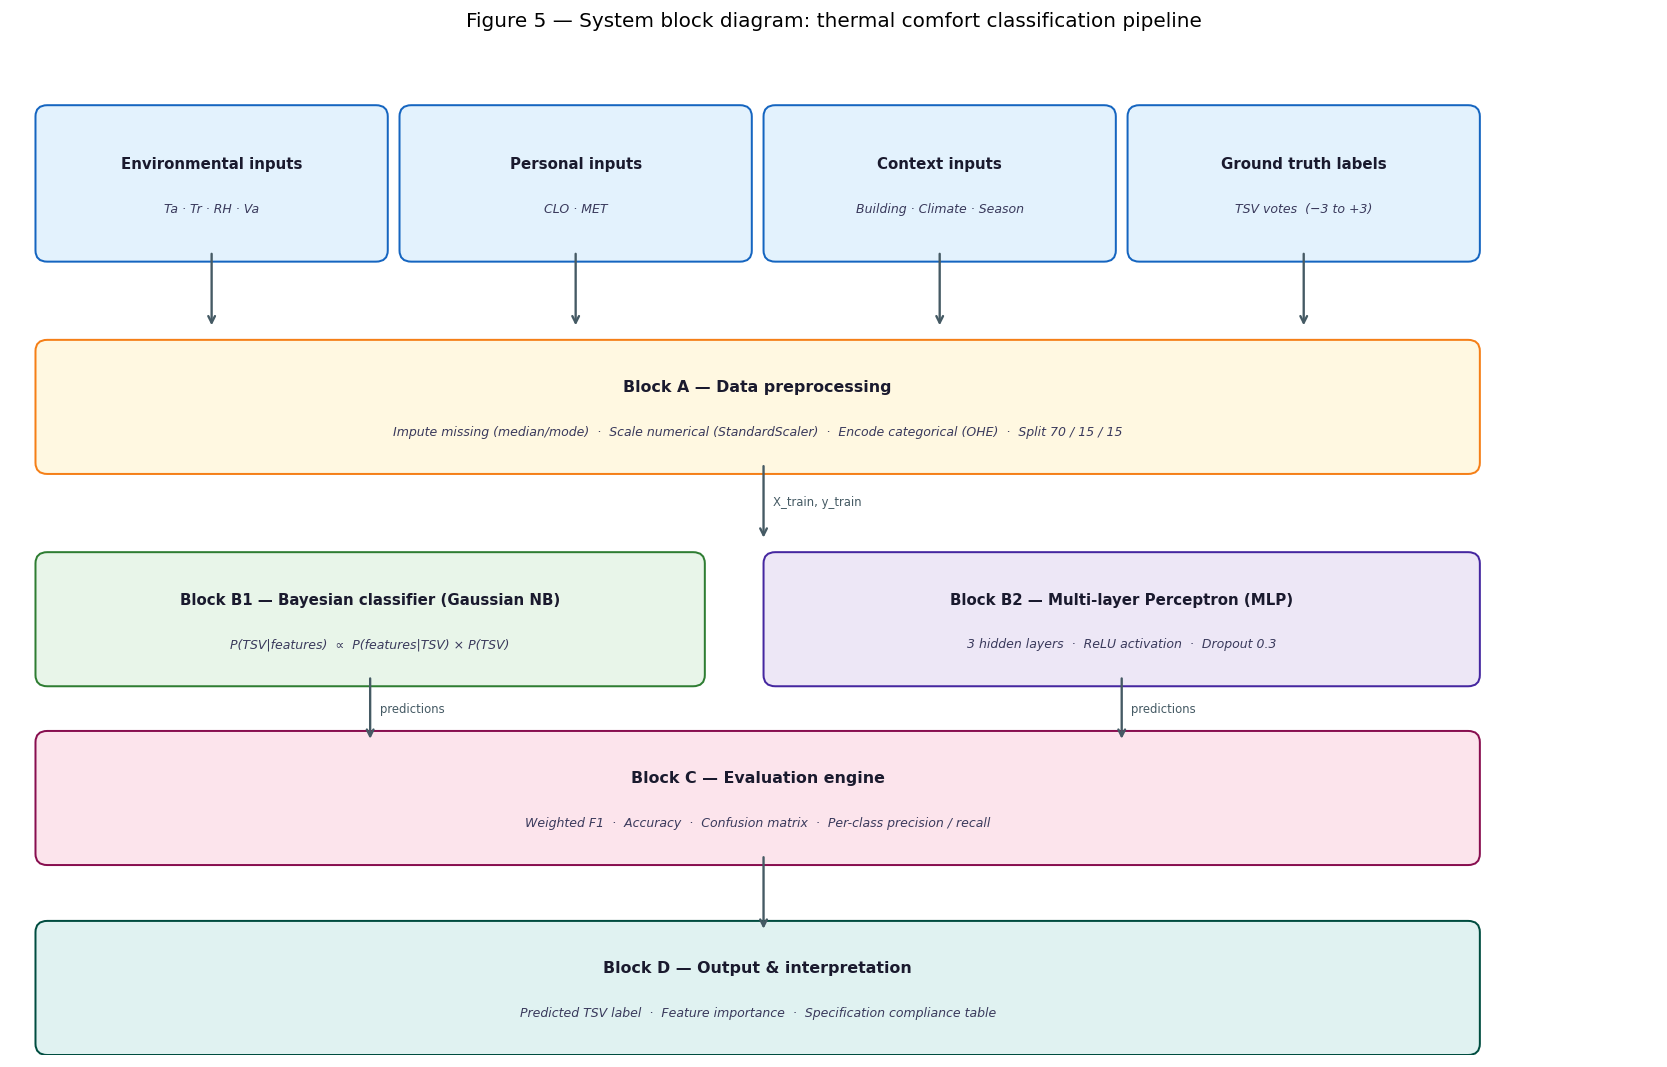

✓ Saved fig5_block_diagram.png


In [2]:
# =============================================================================
# CELL 4: Figure 5 — System block diagram
# We draw this programmatically so it appears in the report PDF
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 14)
ax.set_ylim(0, 9)
ax.axis('off')

def draw_block(ax, x, y, w, h, title, subtitle='', color='#E3F2FD',
               border='#1565C0', fontsize_title=9, fontsize_sub=7.5):
    """Draw a labeled rectangle block."""
    rect = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.1",
        facecolor=color, edgecolor=border, linewidth=1.2
    )
    ax.add_patch(rect)
    cx, cy = x + w/2, y + h/2
    if subtitle:
        ax.text(cx, cy + 0.18, title, ha='center', va='center',
                fontsize=fontsize_title, fontweight='bold', color='#1a1a2e')
        ax.text(cx, cy - 0.22, subtitle, ha='center', va='center',
                fontsize=fontsize_sub, color='#3a3a5c', style='italic')
    else:
        ax.text(cx, cy, title, ha='center', va='center',
                fontsize=fontsize_title, fontweight='bold', color='#1a1a2e')

def arrow(ax, x1, y1, x2, y2, label='', color='#455A64'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.4))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.08, my, label, fontsize=7, color=color, va='center')

# ── Row 1: Input sources ───────────────────────────────────────────────────
input_color   = '#E3F2FD'
input_border  = '#1565C0'
draw_block(ax, 0.3,  7.2, 2.8, 1.2, 'Environmental inputs',
           'Ta · Tr · RH · Va', input_color, input_border)
draw_block(ax, 3.4,  7.2, 2.8, 1.2, 'Personal inputs',
           'CLO · MET', input_color, input_border)
draw_block(ax, 6.5,  7.2, 2.8, 1.2, 'Context inputs',
           'Building · Climate · Season', input_color, input_border)
draw_block(ax, 9.6,  7.2, 2.8, 1.2, 'Ground truth labels',
           'TSV votes  (−3 to +3)', input_color, input_border)

# ── Arrows Row 1 → Row 2 ──────────────────────────────────────────────────
for cx in [1.7, 4.8, 7.9, 11.0]:
    arrow(ax, cx, 7.2, cx, 6.5)

# ── Row 2: Preprocessing block ─────────────────────────────────────────────
draw_block(ax, 0.3, 5.3, 12.1, 1.0,
           'Block A — Data preprocessing',
           'Impute missing (median/mode)  ·  Scale numerical (StandardScaler)'
           '  ·  Encode categorical (OHE)  ·  Split 70 / 15 / 15',
           '#FFF8E1', '#F57F17', fontsize_title=9.5)

arrow(ax, 6.4, 5.3, 6.4, 4.6, label='X_train, y_train')

# ── Row 3: Two algorithm blocks ────────────────────────────────────────────
draw_block(ax, 0.3,  3.4, 5.5, 1.0,
           'Block B1 — Bayesian classifier (Gaussian NB)',
           'P(TSV|features)  ∝  P(features|TSV) × P(TSV)',
           '#E8F5E9', '#2E7D32')
draw_block(ax, 6.5,  3.4, 5.9, 1.0,
           'Block B2 — Multi-layer Perceptron (MLP)',
           '3 hidden layers  ·  ReLU activation  ·  Dropout 0.3',
           '#EDE7F6', '#4527A0')

arrow(ax, 3.05, 3.4, 3.05, 2.8, label='predictions')
arrow(ax, 9.45, 3.4, 9.45, 2.8, label='predictions')

# ── Row 4: Evaluation ──────────────────────────────────────────────────────
draw_block(ax, 0.3, 1.8, 12.1, 1.0,
           'Block C — Evaluation engine',
           'Weighted F1  ·  Accuracy  ·  Confusion matrix  ·  Per-class precision / recall',
           '#FCE4EC', '#880E4F', fontsize_title=9.5)

arrow(ax, 6.4, 1.8, 6.4, 1.1)

# ── Row 5: Output ──────────────────────────────────────────────────────────
draw_block(ax, 0.3, 0.1, 12.1, 1.0,
           'Block D — Output & interpretation',
           'Predicted TSV label  ·  Feature importance  ·  Specification compliance table',
           '#E0F2F1', '#004D40', fontsize_title=9.5)

ax.set_title('Figure 5 — System block diagram: thermal comfort classification pipeline',
             fontsize=12, pad=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5_block_diagram.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Saved fig5_block_diagram.png")

Train : 73,117  (70.0%)
Val   : 15,668  (15.0%)
Test  : 15,669  (15.0%)


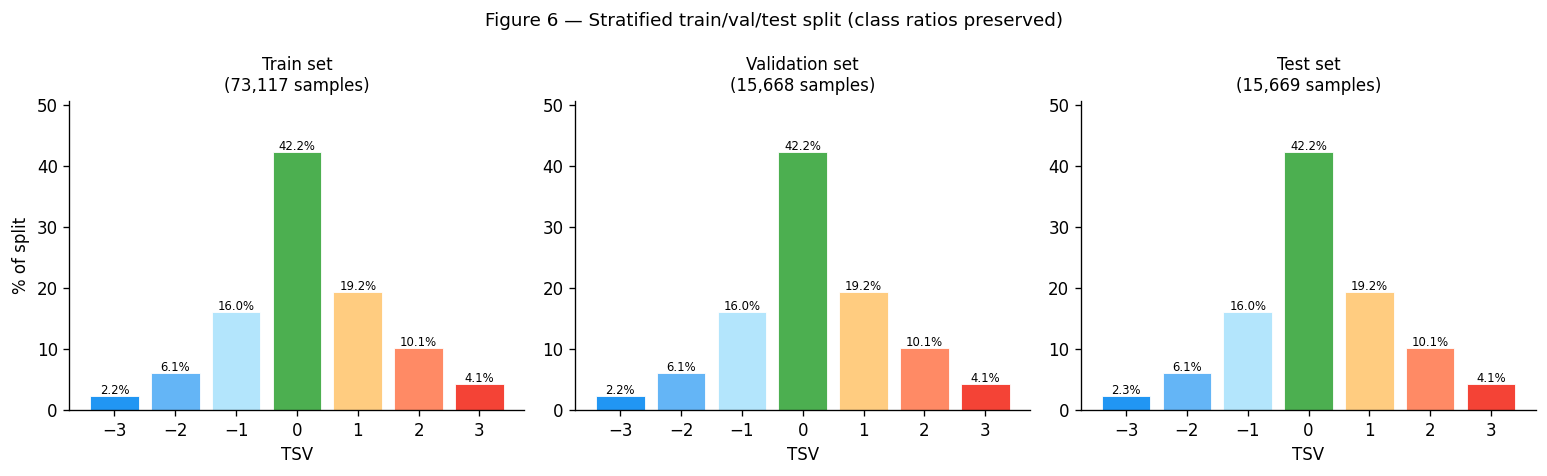

✓ Saved fig6_data_split.png


In [3]:
# =============================================================================
# CELL 5: Figure 6 — Visualise train/val/test split
# Shows that split is stratified (class ratios preserved)
# =============================================================================
from sklearn.model_selection import train_test_split

# Prepare features
NUM_COLS = ['air_temp','radiant','humidity','velocity','clothing','metabolic']
CAT_COLS = ['building','climate','season']

num_cols_present = [c for c in NUM_COLS if c in df.columns]
cat_cols_present = [c for c in CAT_COLS if c in df.columns]

# Drop rows missing the target
df_model = df.dropna(subset=['tsv']).copy()

# Fill missing numerics with median, categoricals with mode
for col in num_cols_present:
    df_model[col] = df_model[col].fillna(df_model[col].median())
for col in cat_cols_present:
    df_model[col] = df_model[col].fillna(df_model[col].mode()[0])

X = df_model[num_cols_present + cat_cols_present]
y = df_model['tsv']

# Stratified split: 70% train, 15% val, 15% test
X_temp, X_test,  y_temp, y_test  = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val,  y_train, y_val  = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=42, stratify=y_temp)

print(f"Train : {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val   : {len(X_val):,}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test  : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)")

# Plot split proportions
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
palette = {-3:'#2196F3',-2:'#64B5F6',-1:'#B3E5FC',
            0:'#4CAF50', 1:'#FFCC80', 2:'#FF8A65', 3:'#F44336'}

for ax, (split_y, name) in zip(axes, [
        (y_train, 'Train'), (y_val, 'Validation'), (y_test, 'Test')]):
    counts = split_y.value_counts(normalize=True).sort_index() * 100
    bars = ax.bar(counts.index, counts.values,
                  color=[palette.get(v,'gray') for v in counts.index],
                  edgecolor='white', linewidth=0.5)
    ax.set_title(f'{name} set\n({len(split_y):,} samples)', fontsize=10)
    ax.set_xlabel('TSV')
    ax.set_ylabel('% of split' if name=='Train' else '')
    ax.set_xticks(counts.index)
    ax.set_ylim(0, counts.max() * 1.2)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f'{val:.1f}%', ha='center', fontsize=7)

plt.suptitle('Figure 6 — Stratified train/val/test split (class ratios preserved)',
             fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_data_split.png', bbox_inches='tight')
plt.show()
print("✓ Saved fig6_data_split.png")

## Acceptance Test Procedures (ATPs)

ATPs are concrete tests that prove each specification is met.
They are run in notebook 05_consolidation.ipynb on the held-out **test set only**.

| ATP ID | Linked Spec | Test Procedure | Pass Criterion |
|--------|-------------|----------------|----------------|
| ATP-1  | SP1 | Compute weighted F1-score of best model on X_test / y_test | F1 ≥ 0.60 |
| ATP-2  | SP2 | Compute accuracy of best model on X_test / y_test | Accuracy ≥ 55% |
| ATP-3  | SP3 | Compute F1 of PMV baseline on same X_test; compare | Best model F1 > PMV F1 |
| ATP-4  | SP4 | Introduce 30% artificial NaN into X_test; re-run pipeline; check no crash | Pipeline completes, F1 degrades < 5 pp |
| ATP-5  | SP5 | Time the full training cell with `%%time` magic | Wall time ≤ 10 min |
| ATP-6  | SP6 | Confirm feature importance figure is saved to figures/ | File exists and is non-empty |
| ATP-7  | SP7 | Print list of features used by best model | ≥ 5 ASHRAE inputs present |

> **Note:** The test set (X_test, y_test) is **never used during training or tuning**.
> It is sealed until the final evaluation in notebook 05.

In [4]:
# =============================================================================
# CELL 7: Save the train/val/test split so all later notebooks use
#         the exact same data — reproducibility is essential
# =============================================================================
import pickle

split = {
    'X_train': X_train, 'y_train': y_train,
    'X_val':   X_val,   'y_val':   y_val,
    'X_test':  X_test,  'y_test':  y_test,
    'num_cols': num_cols_present,
    'cat_cols': cat_cols_present,
}

split_path = DATA_DIR / 'data_split.pkl'
with open(split_path, 'wb') as f:
    pickle.dump(split, f)

print(f"✓ Split saved to {split_path}")
print(f"  Features used: {num_cols_present + cat_cols_present}")
print(f"\nReady for notebook 03!")

✓ Split saved to ..\data\data_split.pkl
  Features used: ['air_temp', 'radiant', 'humidity', 'velocity', 'clothing', 'metabolic', 'building', 'climate', 'season']

Ready for notebook 03!
